<a href="https://colab.research.google.com/github/Yiiize/MSSP6070/blob/main/Assignments/Case_Study_Report_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jekiwantaufik/west-java-2010-2025")

print("Path to dataset files:", path)

100%|██████████| 3.01k/3.01k [00:00<00:00, 4.58MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/jekiwantaufik/west-java-2010-2025/versions/1


In [12]:
from google.colab import userdata
import os

github_token = userdata.get('Git_Key')
owner = 'Yiiize' # Replace with the GitHub repository owner
repository = 'MSSP6070' # Replace with the GitHub repository name

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
import subprocess
subprocess.run(['git', 'clone', clone_url])

# Navigate into the cloned repository directory (optional, but often useful)
os.chdir(repository)
print(f"Changed directory to: {os.getcwd()}")


Changed directory to: /content/MSSP6070/MSSP6070


In [13]:
import os
import pandas as pd

# List files in the kagglehub dataset directory
data_files = os.listdir(path)
print("Files in KaggleHub dataset directory:", data_files)

# Assuming the main data file is a CSV and taking the first CSV file found
csv_file = [f for f in data_files if f.endswith('.csv')][0]
data_file_path = os.path.join(path, csv_file)

# Load the data
try:
    df_kaggle = pd.read_csv(data_file_path)
    print("\nData loaded successfully. First 5 rows:")
    print(df_kaggle.head())

    # Calculate mean and standard deviation
    mean_values = df_kaggle.mean(numeric_only=True)
    std_dev_values = df_kaggle.std(numeric_only=True)

    print("\nMean values of numerical columns:")
    print(mean_values)
    print("\nStandard deviation values of numerical columns:")
    print(std_dev_values)
except Exception as e:
    print(f"Error loading or processing the data: {e}")

Files in KaggleHub dataset directory: ['Population.csv']

Data loaded successfully. First 5 rows:
         Date Province_Name Regency_City_Name  Population
0  2010-01-01     West Java             Bogor      481388
1  2010-01-01     West Java          Sukabumi      235842
2  2010-01-01     West Java           Cianjur      218679
3  2010-01-01     West Java           Bandung      320512
4  2010-01-01     West Java             Garut      242233

Mean values of numerical columns:
Population    196841.138889
dtype: float64

Standard deviation values of numerical columns:
Population    188530.060266
dtype: float64


Shapiro-Wilk Test Statistic: 0.8186, p-value: 0.0000
Sample does not look Gaussian (reject H0)


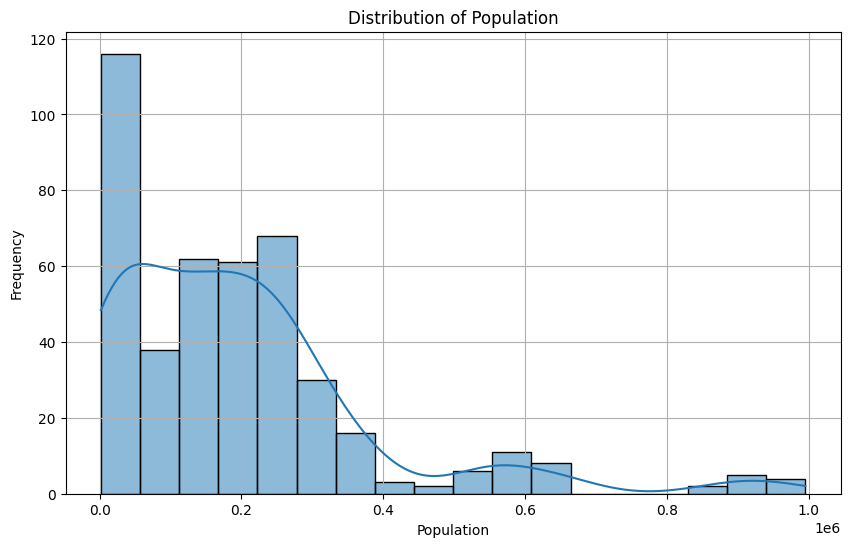

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

# Assuming df_kaggle is already loaded and contains the 'Population' column
if 'df_kaggle' in locals() and 'Population' in df_kaggle.columns:
    population_data = df_kaggle['Population']

    # Shapiro-Wilk Test for normality
    # Null hypothesis (H0): The data is normally distributed.
    # Alternative hypothesis (H1): The data is not normally distributed.
    stat, p = shapiro(population_data)
    print(f'Shapiro-Wilk Test Statistic: {stat:.4f}, p-value: {p:.4f}')

    alpha = 0.05
    if p > alpha:
        print("Sample looks Gaussian (fail to reject H0)")
    else:
        print("Sample does not look Gaussian (reject H0)")

    # Visualize the distribution with a histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(population_data, kde=True)
    plt.title('Distribution of Population')
    plt.xlabel('Population')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()
else:
    print("df_kaggle DataFrame or 'Population' column not found. Please ensure the data is loaded correctly.")


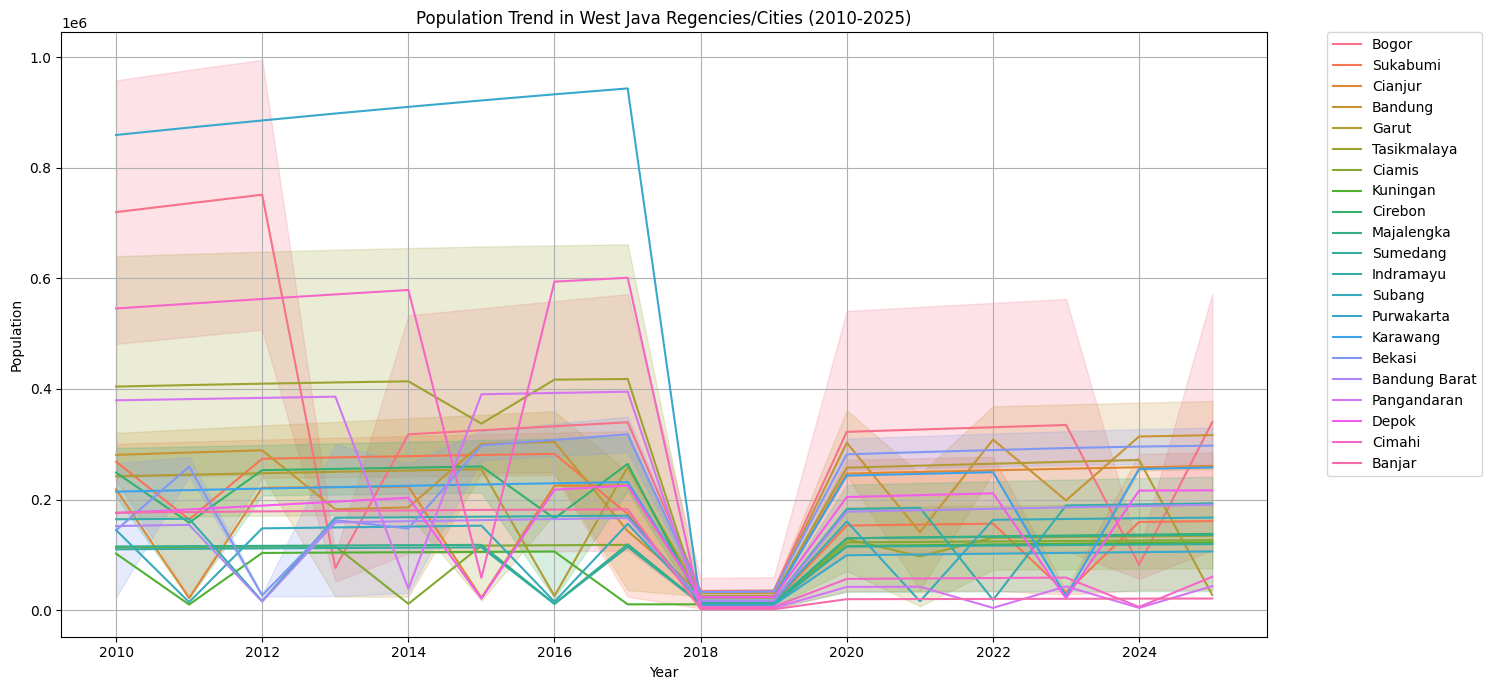

/tmp/ipython-input-2997119884.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_population.values, y=average_population.index, palette='viridis')


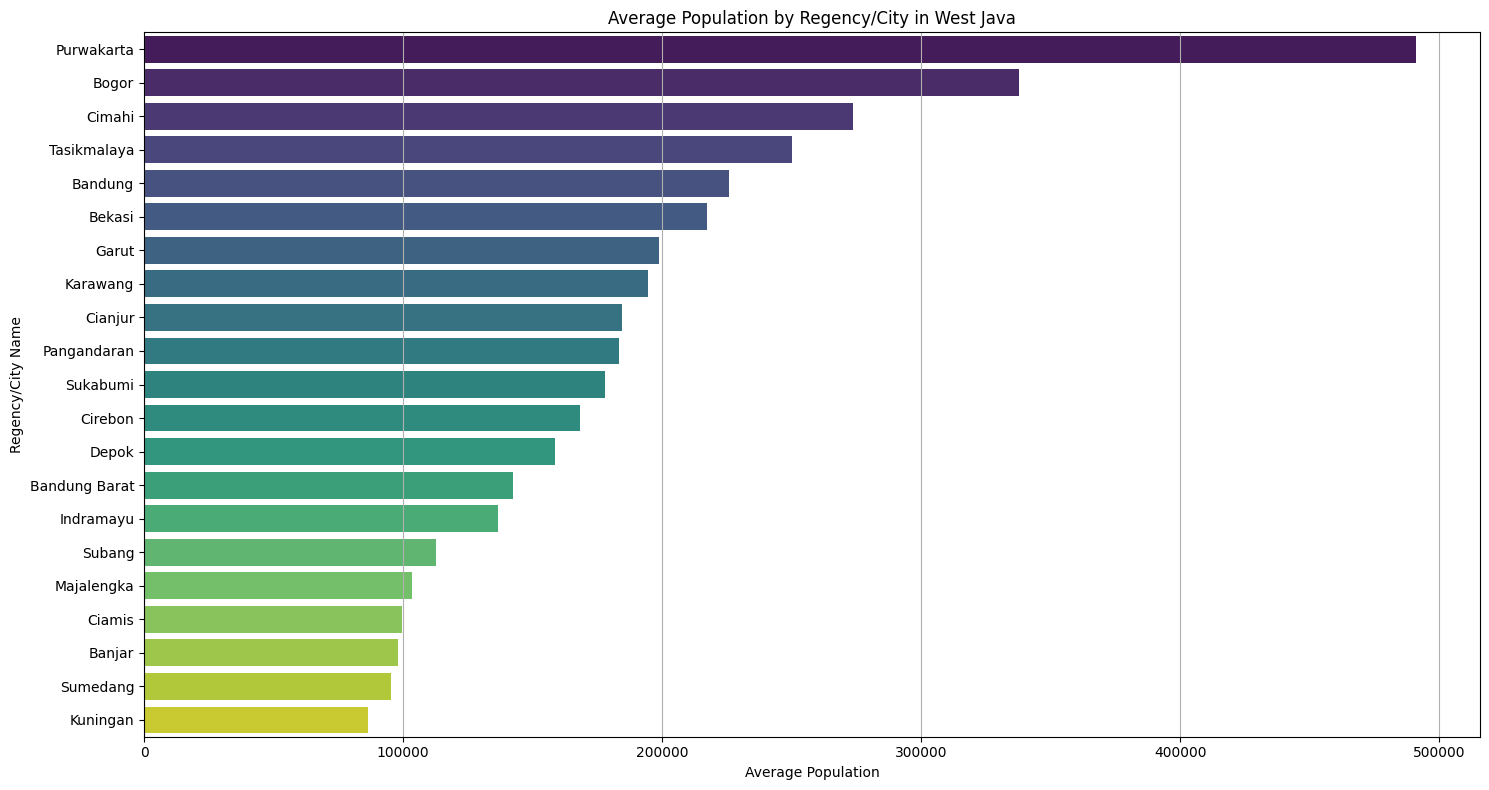

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Date' column is in datetime format
df_kaggle['Date'] = pd.to_datetime(df_kaggle['Date'])

# --- Visualization 1: Population Trend Over Time ---
plt.figure(figsize=(15, 7))
sns.lineplot(data=df_kaggle, x='Date', y='Population', hue='Regency_City_Name')
plt.title('Population Trend in West Java Regencies/Cities (2010-2025)')
plt.xlabel('Year')
plt.ylabel('Population')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

# --- Visualization 2: Average Population by Regency/City ---
# Calculate average population for each regency/city
average_population = df_kaggle.groupby('Regency_City_Name')['Population'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x=average_population.values, y=average_population.index, palette='viridis')
plt.title('Average Population by Regency/City in West Java')
plt.xlabel('Average Population')
plt.ylabel('Regency/City Name')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

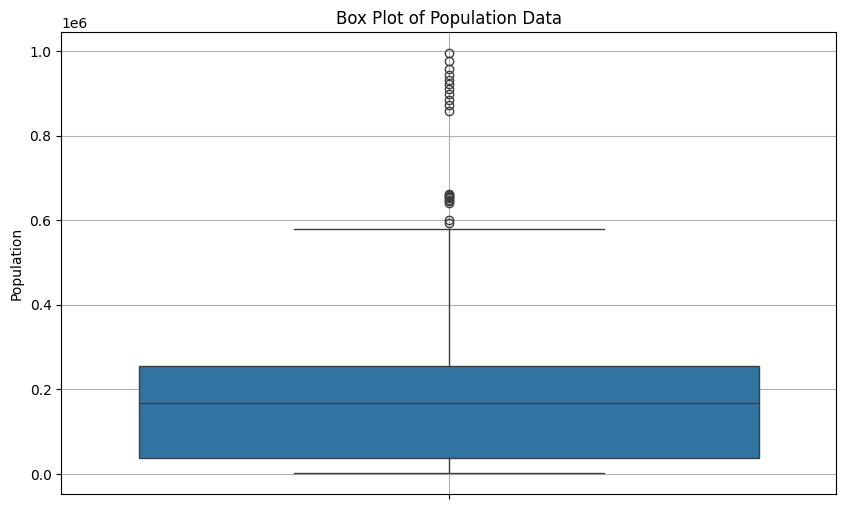


Detected 21 potential outliers:
13     859186
18     958077
25     639987
40     872599
45     976791
52     644305
67     885386
72     995081
79     648178
94     898001
106    651676
121    910007
133    654794
148    921598
160    657477
175    932701
186    594021
187    659606
202    943337
213    601099
214    661404
Name: Population, dtype: int64

Lower bound for outliers: -287685.88
Upper bound for outliers: 582309.12


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df_kaggle is already loaded and contains the 'Population' column
if 'df_kaggle' in locals() and 'Population' in df_kaggle.columns:
    population_data = df_kaggle['Population']

    # Visualize outliers using a box plot
    plt.figure(figsize=(10, 6))
    sns.boxplot(y=population_data)
    plt.title('Box Plot of Population Data')
    plt.ylabel('Population')
    plt.grid(True)
    plt.show()

    # Calculate IQR and identify potential outliers
    Q1 = population_data.quantile(0.25)
    Q3 = population_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = population_data[(population_data < lower_bound) | (population_data > upper_bound)]

    if not outliers.empty:
        print(f"\nDetected {len(outliers)} potential outliers:")
        print(outliers)
        print(f"\nLower bound for outliers: {lower_bound:.2f}")
        print(f"Upper bound for outliers: {upper_bound:.2f}")
    else:
        print("\nNo potential outliers detected based on the 1.5*IQR rule.")

else:
    print("df_kaggle DataFrame or 'Population' column not found. Please ensure the data is loaded correctly.")


Based on the analysis performed so far, here are a few other patterns in the data that are of interest:

Significant Disparity in Population Sizes and Outliers: The bar plot of average population clearly shows that some regencies/cities have much higher average populations than others (e.g., Purwakarta, Bogor, Cimahi stand out). This is reinforced by the outlier detection, where 21 data points were identified as having unusually high populations. This pattern suggests that West Java has a few very large urban centers or administrative regions that significantly exceed the population of most other areas. This disparity is crucial because it indicates a highly uneven distribution of population, which can have implications for resource allocation, infrastructure planning, and socio-economic studies. It also explains why the 'Population' data is not normally distributed – the distribution is skewed towards these larger cities.

Consistent Population Growth Over Time: The line plot illustrating population trends from 2010 to 2025 shows a general upward trend for almost all regencies/cities. While some areas experience faster growth than others, the overall pattern points towards a steadily increasing population across West Java. This consistent growth, without significant dips for any region, indicates sustained development or demographic changes. Analyzing the rates of growth for different regencies/cities could reveal areas of rapid urbanization versus more stable, rural development.

Non-Normal Distribution Reflecting Urbanization: The Shapiro-Wilk test strongly indicated that the 'Population' data is not normally distributed, which is visually supported by the histogram. This non-normal, likely skewed, distribution is a pattern in itself. It tells us that there are many regencies/cities with relatively smaller populations, and fewer with very large populations. This distribution is typical for demographic data, often reflecting urbanization where a few major cities draw a significant portion of the population. Understanding this non-normal pattern is important when choosing appropriate statistical models or analytical methods, as many methods assume normality.

